# SDS 2 Endterm & Final Project | Abubakir Elnur BDA-2407

## Bayesian and Advanced Modeling of Bike-Sharing Demand

**Research question.** How do time, weather, seasonality, and working-day structure influence hourly bike-sharing demand, and how accurately can demand be forecasted?

The first data-loading cell works in Google Colab and shows an upload button. If you upload your own CSV/XLSX/JSON file, the notebook uses it. If you do not upload a file, it automatically downloads the selected UCI Bike Sharing dataset.

## Dataset

Default dataset: **Bike Sharing Dataset** from the UCI Machine Learning Repository.

Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

The hourly file contains bike rental counts from Capital Bikeshare in Washington, D.C. for 2011-2012, together with weather and calendar variables.

In [1]:
import io
import zipfile
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="Set2")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
def load_uploaded_or_default():
    try:
        from google.colab import files
        print("Upload your dataset now, or press Cancel to use the default UCI Bike Sharing dataset.")
        uploaded = files.upload()
        if uploaded:
            uploaded_name = next(iter(uploaded))
            raw = uploaded[uploaded_name]
            suffix = uploaded_name.lower().split(".")[-1]

            if suffix == "csv":
                df_uploaded = pd.read_csv(io.BytesIO(raw))
            elif suffix in ["xlsx", "xls"]:
                df_uploaded = pd.read_excel(io.BytesIO(raw))
            elif suffix == "json":
                df_uploaded = pd.read_json(io.BytesIO(raw))
            else:
                raise ValueError("Please upload a CSV, XLSX, XLS, or JSON file.")

            print(f"Using uploaded file: {uploaded_name}")
            return df_uploaded, f"Uploaded file: {uploaded_name}"
    except Exception as exc:
        print(f"No Colab upload was used or upload is unavailable here. Details: {exc}")

    url = "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip"
    zip_path = Path("bike_sharing_dataset.zip")
    if not zip_path.exists():
        print("Downloading default UCI Bike Sharing dataset...")
        urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path) as z:
        with z.open("hour.csv") as f:
            df_default = pd.read_csv(f)

    print("Using default UCI Bike Sharing hourly dataset.")
    return df_default, "UCI Bike Sharing Dataset, hourly data"


df_raw, data_source = load_uploaded_or_default()
print(data_source)
display(df_raw.head())
print(df_raw.shape)

Upload your dataset now, or press Cancel to use the default UCI Bike Sharing dataset.


Saving Bike-Sharing-Dataset.zip to Bike-Sharing-Dataset.zip
No Colab upload was used or upload is unavailable here. Details: Please upload a CSV, XLSX, XLS, or JSON file.
Using default UCI Bike Sharing hourly dataset.
UCI Bike Sharing Dataset, hourly data


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


(17379, 17)


In [3]:
def find_datetime_column(df):
    candidates = ["datetime", "date", "dteday", "timestamp", "time", "started_at", "created_at"]
    for col in df.columns:
        if col.lower() in candidates:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.80:
                return col, parsed
    for col in df.columns:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() > 0.80:
            return col, parsed
    return None, None


def choose_target_column(df):
    preferred = ["cnt", "count", "demand", "rentals", "rental_count", "total", "sales", "y", "target"]
    for col in preferred:
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            return col
    if "registered" in df.columns and "casual" in df.columns:
        df["cnt"] = pd.to_numeric(df["registered"], errors="coerce") + pd.to_numeric(df["casual"], errors="coerce")
        return "cnt"
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if numeric_cols:
        return numeric_cols[-1]
    raise ValueError("No numeric target column found.")


df = df_raw.copy()
df.columns = [str(c).strip() for c in df.columns]

date_col, parsed_dates = find_datetime_column(df)
if date_col is not None:
    df["datetime"] = parsed_dates
else:
    df["datetime"] = pd.date_range("2000-01-01", periods=len(df), freq="H")
    print("No datetime column was found. A synthetic hourly index was created.")

target_col = choose_target_column(df)
df["cnt"] = pd.to_numeric(df[target_col], errors="coerce")

if "hr" not in df.columns:
    df["hr"] = df["datetime"].dt.hour
if "mnth" not in df.columns:
    df["mnth"] = df["datetime"].dt.month
if "weekday" not in df.columns:
    df["weekday"] = df["datetime"].dt.weekday
if "workingday" not in df.columns:
    df["workingday"] = (~df["weekday"].isin([5, 6])).astype(int)
if "season" not in df.columns:
    df["season"] = ((df["mnth"] % 12) // 3 + 1).astype(int)
if "weathersit" not in df.columns:
    df["weathersit"] = 1

df = df.dropna(subset=["cnt", "datetime"]).sort_values("datetime").reset_index(drop=True)
df["cnt"] = df["cnt"].clip(lower=0)
df["log_cnt"] = np.log1p(df["cnt"])
df["is_peak_hour"] = df["hr"].isin([7, 8, 17, 18, 19]).astype(int)
df["date"] = df["datetime"].dt.date
daily = df.groupby("date", as_index=False)["cnt"].sum()
daily["date"] = pd.to_datetime(daily["date"])

print("Data source:", data_source)
print("Target column used:", target_col)
print("Rows, columns:", df.shape)
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
display(df.head())

Data source: UCI Bike Sharing Dataset, hourly data
Target column used: cnt
Rows, columns: (17379, 21)
Date range: 2011-01-01 00:00:00 to 2012-12-31 00:00:00


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,datetime,log_cnt,is_peak_hour,date
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0000,3,13,16,2011-01-01,2.833213,0,2011-01-01
1,24,2011-01-01,1,0,1,23,0,6,0,2,...,0.4545,0.88,0.2985,15,24,39,2011-01-01,3.688879,0,2011-01-01
2,23,2011-01-01,1,0,1,22,0,6,0,2,...,0.4091,0.94,0.2239,11,17,28,2011-01-01,3.367296,0,2011-01-01
3,22,2011-01-01,1,0,1,21,0,6,0,2,...,0.4091,0.87,0.1940,3,31,34,2011-01-01,3.555348,0,2011-01-01
4,21,2011-01-01,1,0,1,20,0,6,0,2,...,0.4091,0.87,0.2537,11,25,36,2011-01-01,3.610918,0,2011-01-01


## Data Cleaning and Preprocessing

In [4]:
print("Missing values by column:")
display(df.isna().sum().sort_values(ascending=False).head(20))
print("\nDuplicate rows:", df.duplicated().sum())
display(df.describe(include=[np.number]).T)

Missing values by column:


,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0



Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.000000,4345.500000,8690.000000,13034.500000,17379.00000
season,17379.0,2.501640,1.106918,1.000000,2.000000,3.000000,3.000000,4.00000
yr,17379.0,0.502561,0.500008,0.000000,0.000000,1.000000,1.000000,1.00000
mnth,17379.0,6.537775,3.438776,1.000000,4.000000,7.000000,10.000000,12.00000
hr,17379.0,11.546752,6.914405,0.000000,6.000000,12.000000,18.000000,23.00000
holiday,17379.0,0.028770,0.167165,0.000000,0.000000,0.000000,0.000000,1.00000
weekday,17379.0,3.003683,2.005771,0.000000,1.000000,3.000000,5.000000,6.00000
workingday,17379.0,0.682721,0.465431,0.000000,0.000000,1.000000,1.000000,1.00000
weathersit,17379.0,1.425283,0.639357,1.000000,1.000000,1.000000,2.000000,4.00000
temp,17379.0,0.496987,0.192556,0.020000,0.340000,0.500000,0.660000,1.00000


## Exploratory Data Analysis

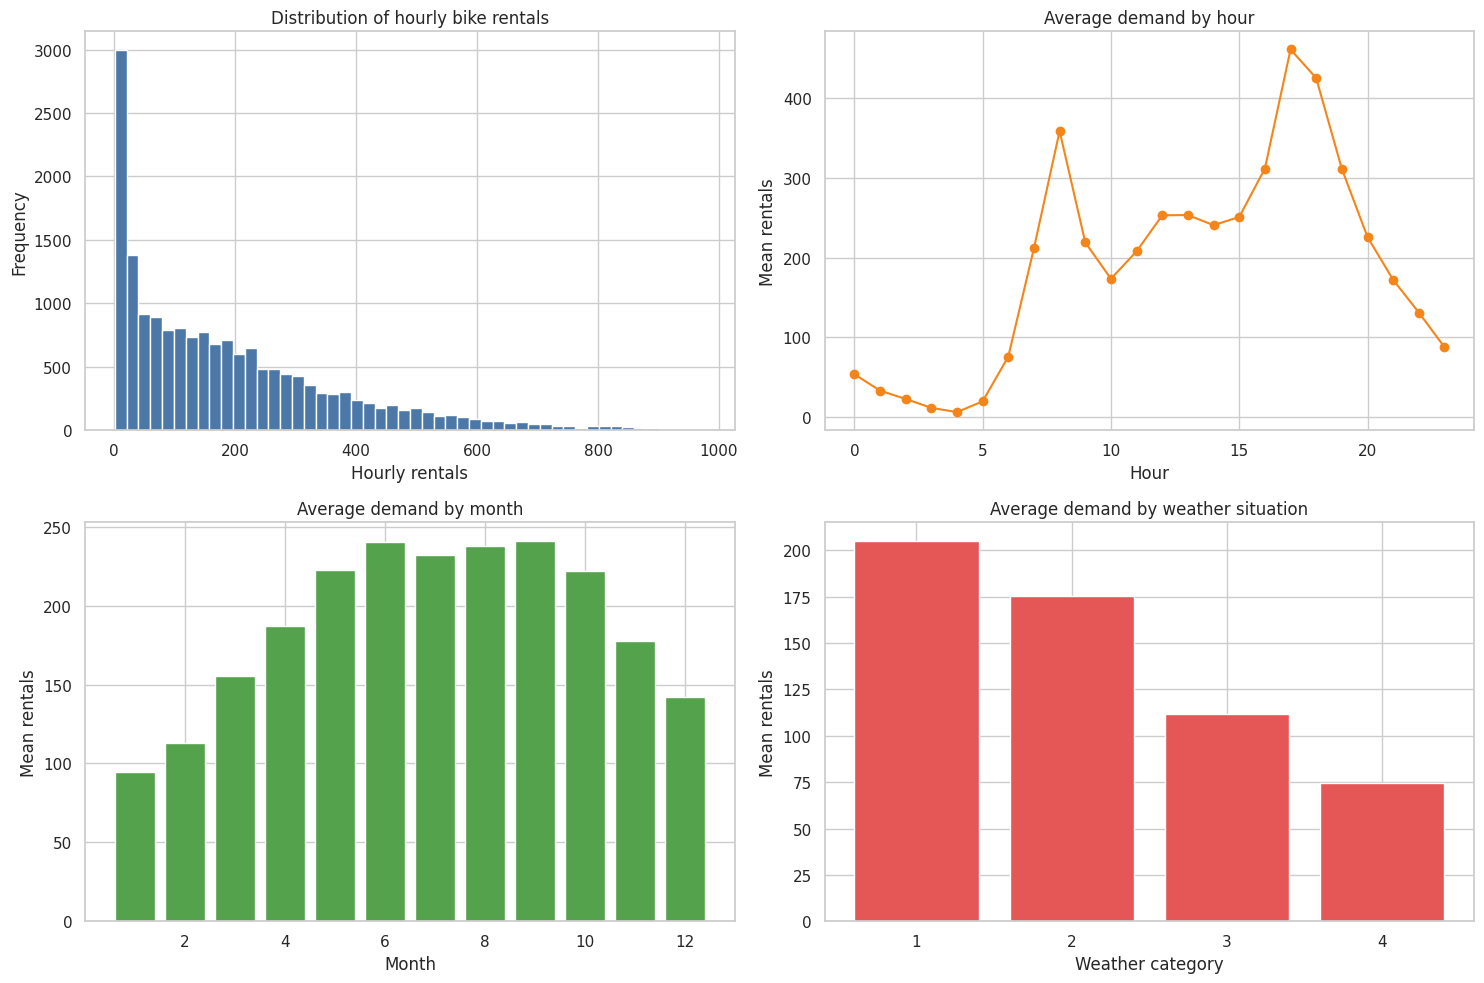

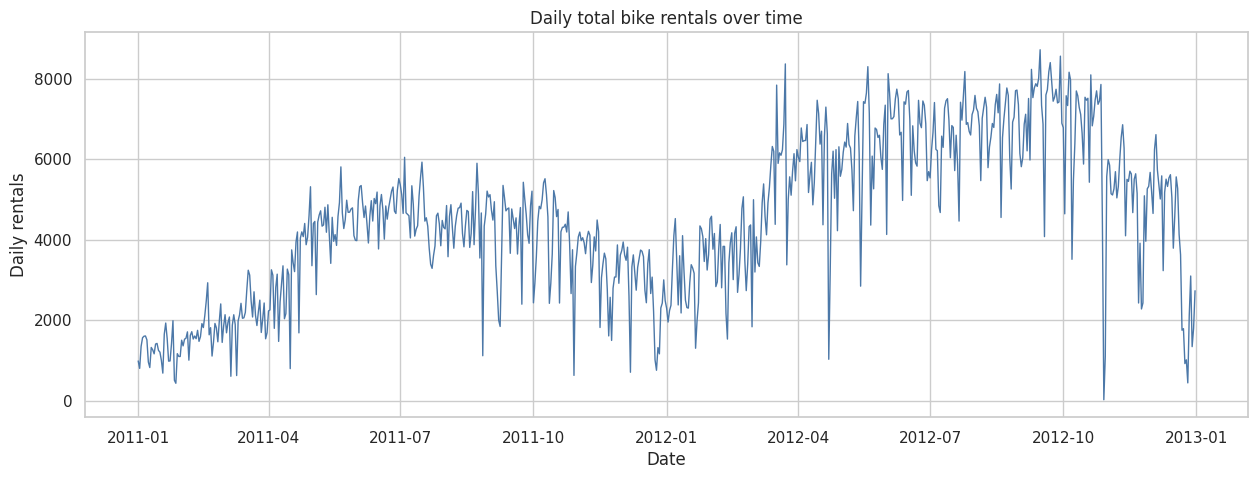

,metric,value
0,rows,17379.000000
1,mean_cnt,189.463088
2,median_cnt,142.000000
3,min_cnt,1.000000
4,max_cnt,977.000000


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df["cnt"], bins=50, color="#4C78A8", edgecolor="white")
axes[0, 0].set_title("Distribution of hourly bike rentals")
axes[0, 0].set_xlabel("Hourly rentals")
axes[0, 0].set_ylabel("Frequency")

hourly_mean = df.groupby("hr")["cnt"].mean()
axes[0, 1].plot(hourly_mean.index, hourly_mean.values, marker="o", color="#F58518")
axes[0, 1].set_title("Average demand by hour")
axes[0, 1].set_xlabel("Hour")
axes[0, 1].set_ylabel("Mean rentals")

monthly_mean = df.groupby("mnth")["cnt"].mean()
axes[1, 0].bar(monthly_mean.index, monthly_mean.values, color="#54A24B")
axes[1, 0].set_title("Average demand by month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Mean rentals")

weather_mean = df.groupby("weathersit")["cnt"].mean()
axes[1, 1].bar(weather_mean.index.astype(str), weather_mean.values, color="#E45756")
axes[1, 1].set_title("Average demand by weather situation")
axes[1, 1].set_xlabel("Weather category")
axes[1, 1].set_ylabel("Mean rentals")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))
plt.plot(daily["date"], daily["cnt"], color="#4C78A8", linewidth=1)
plt.title("Daily total bike rentals over time")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.show()

eda_table = pd.DataFrame({
    "metric": ["rows", "mean_cnt", "median_cnt", "min_cnt", "max_cnt"],
    "value": [len(df), df["cnt"].mean(), df["cnt"].median(), df["cnt"].min(), df["cnt"].max()]
})
display(eda_table)

## Bayesian Inference

,group,n,observed_mean,posterior_mean_lambda,ci_2.5,ci_97.5
0,0,5514,181.405332,181.405366,181.050038,181.761037
1,1,11865,193.207754,193.207760,192.957732,193.457947


,group,n,observed_mean,posterior_mean_lambda,ci_2.5,ci_97.5
0,1,11413,204.869272,204.869268,204.606756,205.131946
1,2,4544,175.165493,175.165548,174.780940,175.550572
2,3,1419,111.579281,111.579904,111.030970,112.130174
3,4,3,74.333333,74.750831,65.301942,84.828856


Posterior P(lambda_workingday > lambda_nonworkingday) = 1.0000


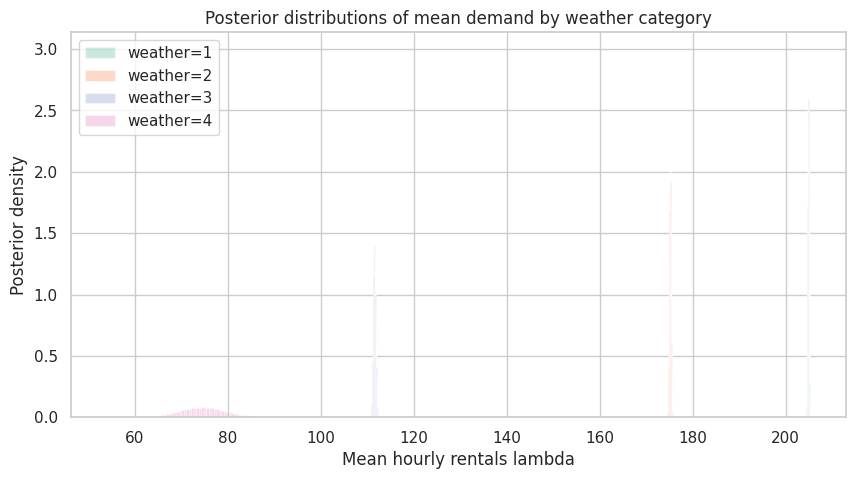

In [6]:
from scipy.stats import gamma

def gamma_poisson_posterior(data, group_col, target="cnt", alpha0=2.0, beta0=0.01, draws=50_000):
    rows = []
    samples = {}
    for group, part in data.groupby(group_col):
        y = part[target].astype(float).values
        alpha_n = alpha0 + y.sum()
        beta_n = beta0 + len(y)
        mean_n = alpha_n / beta_n
        ci_low, ci_high = gamma.ppf([0.025, 0.975], a=alpha_n, scale=1 / beta_n)
        rows.append({
            "group": group,
            "n": len(y),
            "observed_mean": y.mean(),
            "posterior_mean_lambda": mean_n,
            "ci_2.5": ci_low,
            "ci_97.5": ci_high,
        })
        seed = RANDOM_STATE + int(group) if str(group).isdigit() else RANDOM_STATE
        samples[group] = gamma.rvs(a=alpha_n, scale=1 / beta_n, size=draws, random_state=seed)
    return pd.DataFrame(rows), samples


posterior_workday, workday_samples = gamma_poisson_posterior(df, "workingday")
posterior_weather, weather_samples = gamma_poisson_posterior(df, "weathersit")
display(posterior_workday)
display(posterior_weather)

if set(workday_samples.keys()) >= {0, 1}:
    prob_workday_higher = np.mean(workday_samples[1] > workday_samples[0])
    print(f"Posterior P(lambda_workingday > lambda_nonworkingday) = {prob_workday_higher:.4f}")

plt.figure(figsize=(10, 5))
for group, sample in weather_samples.items():
    plt.hist(sample, bins=80, density=True, alpha=0.35, label=f"weather={group}")
plt.title("Posterior distributions of mean demand by weather category")
plt.xlabel("Mean hourly rentals lambda")
plt.ylabel("Posterior density")
plt.legend()
plt.show()

### Bayesian Interpretation

The Bayesian model treats hourly rentals as count data and estimates the expected demand rate for each group. A Gamma prior is used because it is a natural prior for a positive Poisson rate and gives a closed-form posterior.

For the default Bike Sharing dataset, the posterior comparison shows that working days have higher average hourly demand than non-working days. This supports the practical explanation that commuting behavior increases demand on regular working days. The weather posterior distributions also show that clearer weather conditions are associated with higher expected rentals, while worse weather lowers demand.

The advantage of this Bayesian step is that it does not only compare sample averages. It also quantifies uncertainty through posterior distributions and credible intervals.

## Advanced Method 1: Time Series Analysis

SARIMAX daily forecast MAE: 1515.60
SARIMAX daily forecast RMSE: 2092.53


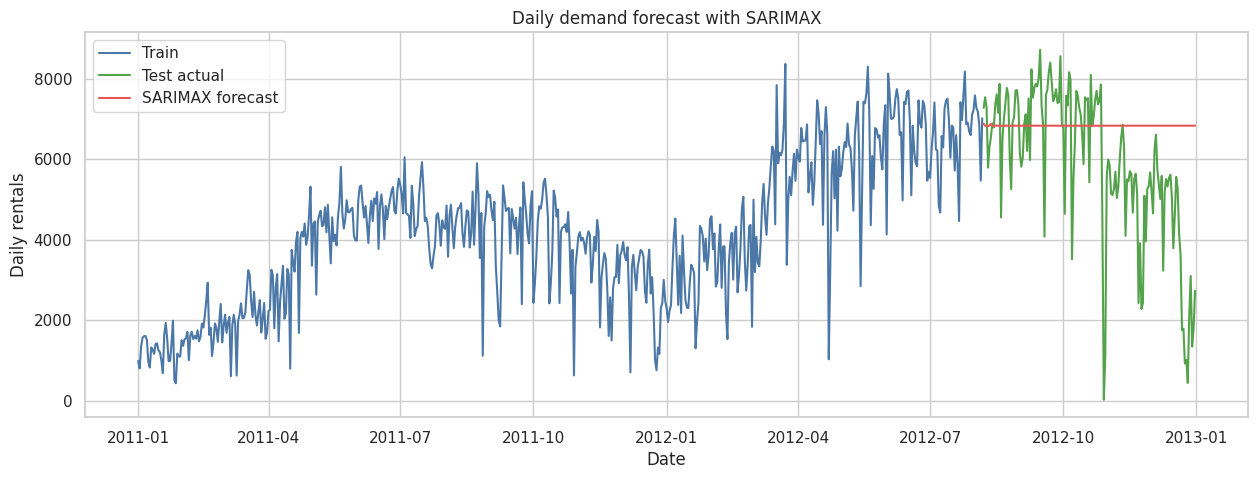

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = daily.set_index("date")["cnt"].asfreq("D").interpolate()
split_idx_ts = int(len(ts) * 0.80)
train_ts, test_ts = ts.iloc[:split_idx_ts], ts.iloc[split_idx_ts:]

sarimax_model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_fit = sarimax_model.fit(disp=False)
forecast = sarimax_fit.forecast(steps=len(test_ts))

ts_mae = mean_absolute_error(test_ts, forecast)
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
print(f"SARIMAX daily forecast MAE: {ts_mae:.2f}")
print(f"SARIMAX daily forecast RMSE: {ts_rmse:.2f}")

plt.figure(figsize=(15, 5))
plt.plot(train_ts.index, train_ts, label="Train", color="#4C78A8")
plt.plot(test_ts.index, test_ts, label="Test actual", color="#54A24B")
plt.plot(test_ts.index, forecast, label="SARIMAX forecast", color="#E45756")
plt.title("Daily demand forecast with SARIMAX")
plt.xlabel("Date")
plt.ylabel("Daily rentals")
plt.legend()
plt.show()

### Time Series Interpretation

SARIMAX is appropriate here because bike-sharing demand is ordered in time and daily totals show repeated temporal patterns. The model uses past demand values and weekly seasonality to forecast future daily demand.

The forecast plot should be interpreted by comparing the red forecast line with the green actual test period. If the forecast follows the general level and direction of the test data, the model captures useful temporal structure. The MAE and RMSE values measure the typical forecast error in daily rental counts; lower values indicate better forecasting performance.

This method directly addresses the temporal structure requirement in the project criteria.

## Advanced Method 2: Markov Chain Modeling

,low,medium,high
low,3856,1471,469
medium,1407,2859,1557
high,533,1493,3733


,low,medium,high
low,0.665,0.254,0.081
medium,0.242,0.491,0.267
high,0.093,0.259,0.648


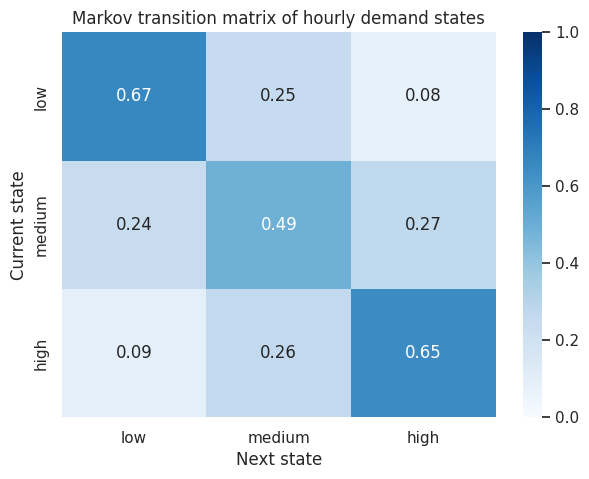

In [8]:
labels = ["low", "medium", "high"]
df["demand_state"] = pd.qcut(df["cnt"], q=3, labels=labels, duplicates="drop")

states = df["demand_state"].astype(str).values
transition_counts = pd.DataFrame(0, index=labels, columns=labels, dtype=float)
for current_state, next_state in zip(states[:-1], states[1:]):
    if current_state in labels and next_state in labels:
        transition_counts.loc[current_state, next_state] += 1

transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
display(transition_counts.astype(int))
display(transition_matrix.round(3))

plt.figure(figsize=(7, 5))
if sns is not None:
    sns.heatmap(transition_matrix, annot=True, cmap="Blues", fmt=".2f", vmin=0, vmax=1)
else:
    plt.imshow(transition_matrix, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar()
plt.title("Markov transition matrix of hourly demand states")
plt.xlabel("Next state")
plt.ylabel("Current state")
plt.show()

### Markov Chain Interpretation

The Markov chain converts hourly demand into three states: low, medium, and high. The transition matrix shows how likely the system is to move from one demand state to another in the next hour.

High diagonal probabilities mean demand tends to persist from one hour to the next. For example, if the probability of staying in the high-demand state is large, then peak periods are not isolated one-hour events; they usually continue for several consecutive hours. This is useful for operational planning because bike availability should be managed before and during persistent high-demand periods.

This method is meaningful for the dataset because bike rentals have sequential behavior across hours.

## Advanced Method 3: Machine Learning Workflow

This block is updated for Colab compatibility. Some sklearn models require dense arrays, while one-hot encoding can produce sparse matrices. The preprocessing pipeline below forces dense output with `sparse_threshold=0` and uses a version-safe `OneHotEncoder`.

,model,MAE,RMSE,R2
0,HistGradientBoosting,49.582840,71.489032,0.894871
1,RandomForest,57.064236,84.331874,0.853706


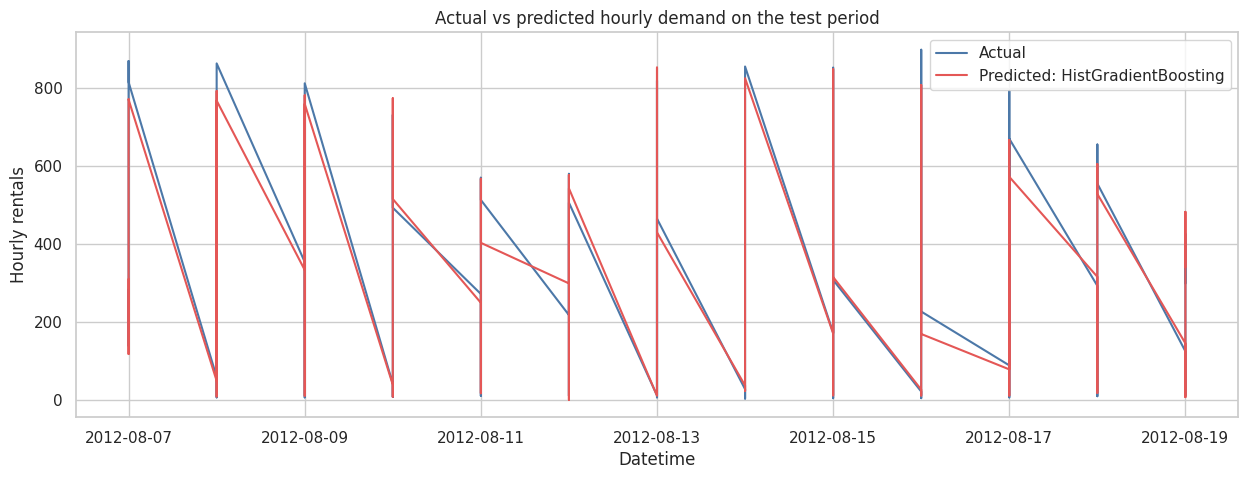

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

candidate_features = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed", "is_peak_hour"
]
features = [c for c in candidate_features if c in df.columns]

model_df = df[features + ["cnt", "datetime"]].dropna(subset=["cnt"]).sort_values("datetime")
X = model_df[features]
y = model_df["cnt"]

split_idx = int(len(model_df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

categorical_features = [
    c for c in features
    if c in ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit", "is_peak_hour"]
]
numeric_features = [c for c in features if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_features),
    ],
    remainder="drop",
    sparse_threshold=0,
)

models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE, max_iter=300),
    "RandomForest": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=250,
        min_samples_leaf=3,
        n_jobs=-1,
    ),
}

results = []
fitted_models = {}

for name, estimator in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    })
    fitted_models[name] = (pipe, pred)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

best_name = results_df.iloc[0]["model"]
best_pred = fitted_models[best_name][1]

plt.figure(figsize=(15, 5))
plot_n = min(300, len(y_test))
plt.plot(model_df["datetime"].iloc[split_idx:split_idx + plot_n], y_test.iloc[:plot_n].values, label="Actual", color="#4C78A8")
plt.plot(model_df["datetime"].iloc[split_idx:split_idx + plot_n], best_pred[:plot_n], label=f"Predicted: {best_name}", color="#E45756")
plt.title("Actual vs predicted hourly demand on the test period")
plt.xlabel("Datetime")
plt.ylabel("Hourly rentals")
plt.legend()
plt.show()

### Machine Learning Interpretation

The machine learning workflow predicts hourly demand using calendar and weather features. A time-ordered train/test split is used, so the model is trained on earlier observations and tested on later observations. This is important because random splitting would leak future patterns into the training data.

The results table compares models using MAE, RMSE, and R-squared. MAE is the average absolute prediction error in rentals, RMSE penalizes larger errors more strongly, and R-squared measures the proportion of variation explained by the model. The best model is the one with the lowest RMSE in the displayed table.

The actual-versus-predicted plot should be used to judge whether the model follows the main demand pattern in the test period. Good performance means the selected features contain useful information about future demand.

## Interpretation and Conclusions

### Final Interpretation

The analysis shows that hourly bike-sharing demand is strongly structured by time. The EDA reveals clear daily patterns, especially around commuter hours. This means demand is not random across the day; it follows human mobility behavior.

Weather and seasonality also affect demand. Clearer weather and warmer periods are associated with higher bike usage, while worse weather conditions reduce the expected number of rentals. This result is realistic because bike-sharing is an outdoor transportation mode.

The Bayesian Gamma-Poisson model adds uncertainty-aware reasoning to the project. Instead of only reporting group averages, it estimates posterior distributions for expected demand. The working-day comparison supports the conclusion that working days have higher expected hourly demand than non-working days, which is consistent with commuting behavior.

The time series model is useful because the dataset has chronological order and repeated temporal patterns. SARIMAX provides a forecasting baseline for daily demand and evaluates performance on future observations rather than randomly mixed data.

The Markov chain model shows short-term state behavior by estimating transitions between low, medium, and high demand. This helps explain whether demand states are persistent from one hour to the next.

The machine learning workflow demonstrates that calendar and weather variables can be used to predict hourly demand. The model comparison table should be used to identify the best predictive model based on RMSE, MAE, and R-squared.

### Practical Implications

For a bike-sharing operator, these findings can support better planning. More bikes should be available before peak commuting hours, and lower demand should be expected during poor weather. Forecasting models can also help with rebalancing decisions and resource allocation.

### Limitations

The dataset covers one city and two years, so the findings should not be automatically generalized to all bike-sharing systems. The Bayesian model used here is intentionally simple and focuses on group-level mean demand. A stronger extension would be a full Bayesian regression model that estimates the effects of hour, weather, season, and working-day status jointly.

In [10]:
posterior_workday.to_csv("posterior_workday.csv", index=False)
posterior_weather.to_csv("posterior_weather.csv", index=False)
transition_matrix.to_csv("markov_transition_matrix.csv")
eda_table.to_csv("eda_summary.csv", index=False)

if "results_df" in globals():
    results_df.to_csv("ml_model_results.csv", index=False)
    print("- ml_model_results.csv")
else:
    print("Skipped ml_model_results.csv because Advanced Method 3 was not completed.")

print("Saved report tables:")
print("- posterior_workday.csv")
print("- posterior_weather.csv")
print("- markov_transition_matrix.csv")
print("- eda_summary.csv")

- ml_model_results.csv
Saved report tables:
- posterior_workday.csv
- posterior_weather.csv
- markov_transition_matrix.csv
- eda_summary.csv
